In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier


# **Before balanced dataset( ON IMBALANCED DATASET)**

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/case_study/fertility.csv")

In [4]:
print("Rows:", df.shape[0], "| Colums:", df.shape[1])

Rows: 880 | Colums: 13


In [5]:
df.head(100)

,N,P,K,pH,EC,OC,S,Zn,Fe,Cu,Mn,B,Output
0,138,8.6,560,7.46,0.62,0.70,5.90,0.24,0.31,0.77,8.71,0.11,0
1,213,7.5,338,7.62,0.75,1.06,25.40,0.30,0.86,1.54,2.89,2.29,0
2,163,9.6,718,7.59,0.51,1.11,14.30,0.30,0.86,1.57,2.70,2.03,0
3,157,6.8,475,7.64,0.58,0.94,26.00,0.34,0.54,1.53,2.65,1.82,0
4,270,9.9,444,7.63,0.40,0.86,11.80,0.25,0.76,1.69,2.43,2.26,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,151,5.9,581,7.60,0.48,0.88,4.52,0.42,4.05,1.06,5.30,0.29,0
96,75,7.9,327,7.80,0.66,0.10,7.24,0.50,7.32,0.87,6.32,0.40,0
97,232,5.9,275,7.70,0.43,0.68,5.43,0.47,6.52,1.52,8.05,0.32,0
98,207,7.5,549,7.70,0.72,0.49,3.32,0.36,4.56,1.96,13.02,0.67,0


In [6]:
print("Rows:", df.shape[0], "| Columns:", df.shape[1])

Rows: 880 | Columns: 13


In [7]:
df.sample(5)

,N,P,K,pH,EC,OC,S,Zn,Fe,Cu,Mn,B,Output
580,270,11.8,781,7.40,0.46,1.17,9.95,0.33,6.02,1.09,13.25,0.32,1
699,351,5.7,581,7.40,0.61,0.78,5.80,0.44,1.13,0.22,21.32,1.49,1
399,163,7.7,507,7.14,0.31,0.88,5.43,0.56,9.52,0.95,4.96,0.48,0
360,220,7.5,539,7.05,0.38,0.68,12.07,0.43,8.52,0.78,8.62,0.29,0
581,257,6.6,401,7.90,0.61,0.10,8.45,0.38,4.96,1.57,9.36,0.50,0


In [8]:
df.isna().sum()


,0
N,0
P,0
K,0
pH,0
EC,0
OC,0
S,0
Zn,0
Fe,0
Cu,0


In [9]:
features = ["N","P","K","pH","EC","OC","S","Zn","Fe","Cu","Mn","B"]
X = df[features]
y = df["Output"]


# **Datatset Splitting**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [12]:
lr = LogisticRegression(max_iter=5000, C=1.5, solver="lbfgs")

knn = KNeighborsClassifier(
    n_neighbors=7,
    weights="distance",
    metric="minkowski"
)

dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=8,
    min_samples_leaf=3,
    random_state=42
)

nb = GaussianNB()


In [13]:
lr.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)

dt.fit(X_train, y_train)
nb.fit(X_train, y_train)


GaussianNB()

In [14]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_knn = knn.predict(X_test_scaled)
y_pred_dt = dt.predict(X_test)
y_pred_nb = nb.predict(X_test)


In [15]:
def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted")
    rec = recall_score(y_true, y_pred, average="weighted")
    print(f"{name} -> Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}")

evaluate("Logistic Regression", y_test, y_pred_lr)
evaluate("KNN", y_test, y_pred_knn)
evaluate("Decision Tree", y_test, y_pred_dt)
evaluate("Naive Bayes", y_test, y_pred_nb)


Logistic Regression -> Accuracy: 0.8580, Precision: 0.8246, Recall: 0.8580
KNN -> Accuracy: 0.8011, Precision: 0.7656, Recall: 0.8011
Decision Tree -> Accuracy: 0.8352, Precision: 0.8321, Recall: 0.8352
Naive Bayes -> Accuracy: 0.4943, Precision: 0.7622, Recall: 0.4943


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)
print("NB Accuracy (scaled):", accuracy_score(y_test, y_pred_nb))


NB Accuracy (scaled): 0.4943181818181818


In [17]:
from sklearn.naive_bayes import ComplementNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

scaler = MinMaxScaler()   # NB variants prefer non-negative
X_train_minmax = scaler.fit_transform(X_train)
X_test_minmax = scaler.transform(X_test)

cnb = ComplementNB()
cnb.fit(X_train_minmax, y_train)

y_pred_cnb = cnb.predict(X_test_minmax)
print("ComplementNB Accuracy:", accuracy_score(y_test, y_pred_cnb))


ComplementNB Accuracy: 0.7670454545454546


In [18]:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

kbd = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile")
X_train_bin = kbd.fit_transform(X_train)
X_test_bin = kbd.transform(X_test)

mnb = MultinomialNB()
mnb.fit(X_train_bin, y_train)

print("MultinomialNB (binned) Accuracy:", accuracy_score(y_test, mnb.predict(X_test_bin)))


MultinomialNB (binned) Accuracy: 0.8409090909090909


In [19]:
scores = cross_val_score(dt, X, y, cv=5, scoring="accuracy")
print("Decision Tree CV Accuracy:", scores.mean())

Decision Tree CV Accuracy: 0.8284090909090909


# **Random Forest ( without balanced)**

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Accuracy: 0.8920454545454546


In [21]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)
xgb.fit(X_train, y_train)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb.predict(X_test)))


XGBoost Accuracy: 0.8806818181818182


In [22]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def summarize_model(name, y_true, y_pred):
    return {
        "Algorithm": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (weighted)": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall (weighted)": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-score (weighted)": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

results = []

# Baseline models
results.append(summarize_model("Logistic Regression", y_test, lr.predict(X_test_scaled)))
results.append(summarize_model("KNN", y_test, knn.predict(X_test_scaled)))
results.append(summarize_model("Decision Tree", y_test, dt.predict(X_test)))
results.append(summarize_model("Naive Bayes (Gaussian)", y_test, nb.predict(X_test_scaled)))

# Improved NB variants
results.append(summarize_model("Naive Bayes (Complement)", y_test, cnb.predict(X_test_minmax)))
results.append(summarize_model("Naive Bayes (Multinomial + Binning)", y_test, mnb.predict(X_test_bin)))

# Ensemble models
results.append(summarize_model("Random Forest", y_test, y_pred_rf))
results.append(summarize_model("XGBoost", y_test, xgb.predict(X_test)))


summary_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
summary_df


,Algorithm,Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted)
6,Random Forest,0.892045,0.852106,0.892045,0.871395
7,XGBoost,0.880682,0.877006,0.880682,0.878711
0,Logistic Regression,0.857955,0.824553,0.857955,0.838259
5,Naive Bayes (Multinomial + Binning),0.840909,0.805718,0.840909,0.821294
2,Decision Tree,0.835227,0.832063,0.835227,0.833577
1,KNN,0.801136,0.765625,0.801136,0.782609
4,Naive Bayes (Complement),0.767045,0.732171,0.767045,0.749086
3,Naive Bayes (Gaussian),0.494318,0.762175,0.494318,0.379015


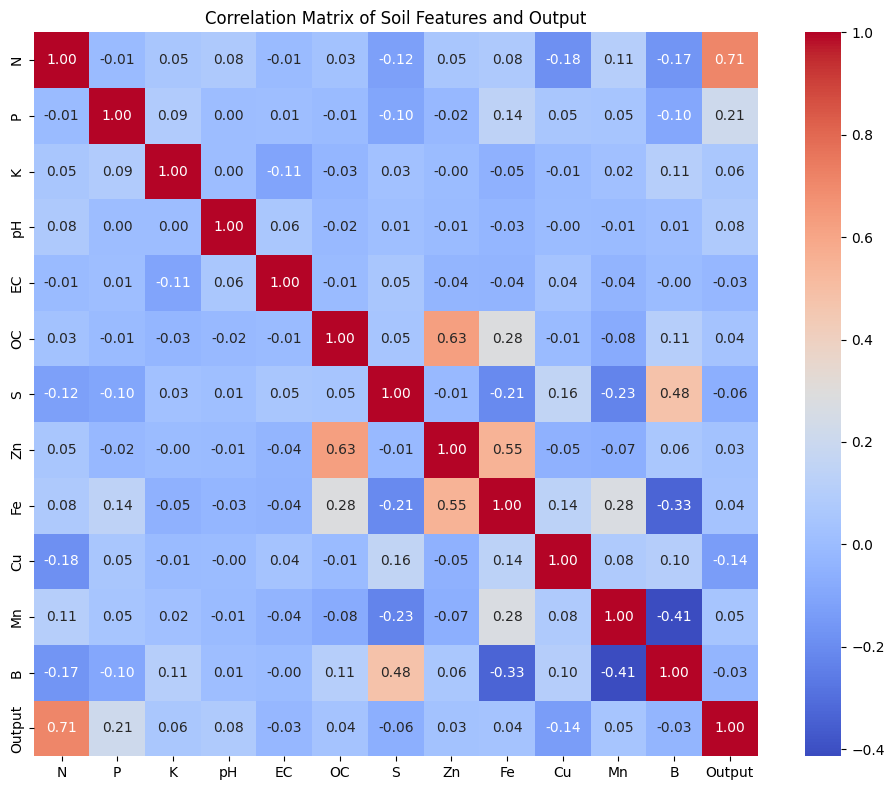

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
corr = df[features + ["Output"]].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix of Soil Features and Output")
plt.tight_layout()
plt.show()


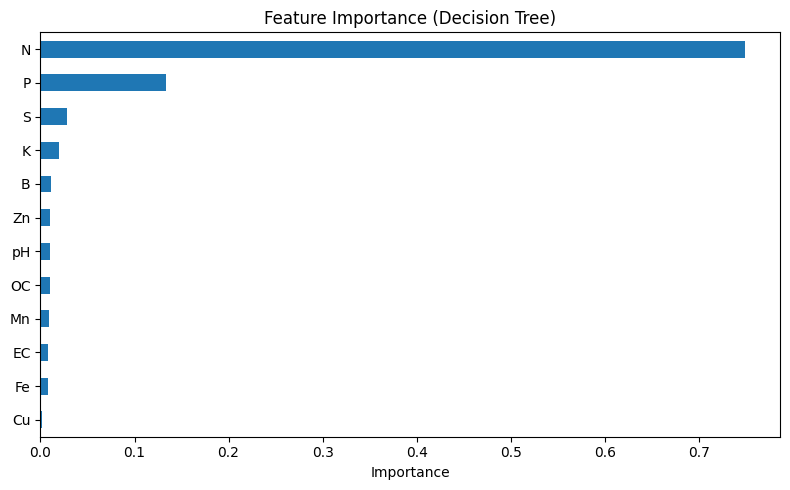

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

fi = pd.Series(dt.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8,5))
fi.plot(kind="barh")
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Predictions
y_pred_lr  = lr.predict(X_test_scaled)
y_pred_knn = knn.predict(X_test_scaled)
y_pred_dt  = dt.predict(X_test)
y_pred_nb  = nb.predict(X_test_scaled)  # or use cnb/mnb if you prefer
y_pred_rf  = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

# Metrics dict
metrics = {
    "Logistic Regression": {
        "acc": accuracy_score(y_test, y_pred_lr),
        "prec": precision_score(y_test, y_pred_lr, average="weighted", zero_division=0),
        "rec": recall_score(y_test, y_pred_lr, average="weighted", zero_division=0),
    },
    "KNN": {
        "acc": accuracy_score(y_test, y_pred_knn),
        "prec": precision_score(y_test, y_pred_knn, average="weighted", zero_division=0),
        "rec": recall_score(y_test, y_pred_knn, average="weighted", zero_division=0),
    },
    "Naive Bayes": {
        "acc": accuracy_score(y_test, y_pred_nb),
        "prec": precision_score(y_test, y_pred_nb, average="weighted", zero_division=0),
        "rec": recall_score(y_test, y_pred_nb, average="weighted", zero_division=0),
    },
    "Decision Tree": {
        "acc": accuracy_score(y_test, y_pred_dt),
        "prec": precision_score(y_test, y_pred_dt, average="weighted", zero_division=0),
        "rec": recall_score(y_test, y_pred_dt, average="weighted", zero_division=0),
    },
    "Random Forest": {
        "acc": accuracy_score(y_test, y_pred_rf),
        "prec": precision_score(y_test, y_pred_rf, average="weighted", zero_division=0),
        "rec": recall_score(y_test, y_pred_rf, average="weighted", zero_division=0),
    },
    "XGBoost": {
        "acc": accuracy_score(y_test, y_pred_xgb),
        "prec": precision_score(y_test, y_pred_xgb, average="weighted", zero_division=0),
        "rec": recall_score(y_test, y_pred_xgb, average="weighted", zero_division=0),
    },
}


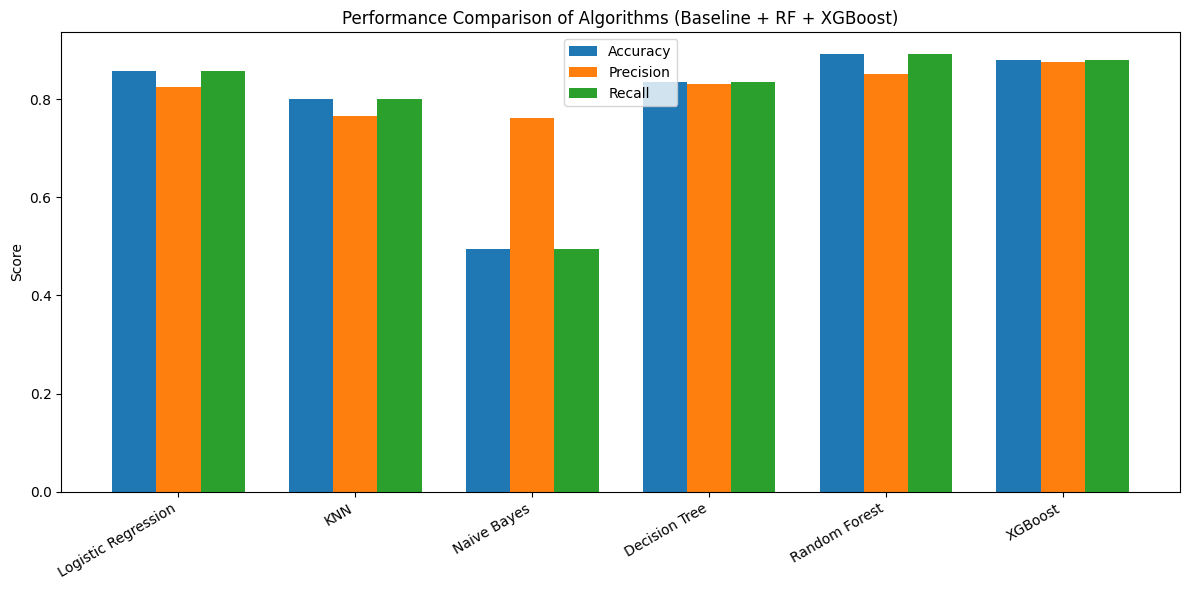

In [26]:
import numpy as np
import matplotlib.pyplot as plt

algorithms = list(metrics.keys())
accuracy = [metrics[a]["acc"] for a in algorithms]
precision = [metrics[a]["prec"] for a in algorithms]
recall = [metrics[a]["rec"] for a in algorithms]

x = np.arange(len(algorithms))
width = 0.25

plt.figure(figsize=(12,6))
plt.bar(x - width, accuracy, width, label="Accuracy")
plt.bar(x, precision, width, label="Precision")
plt.bar(x + width, recall, width, label="Recall")

plt.xticks(x, algorithms, rotation=30, ha="right")
plt.ylabel("Score")
plt.title("Performance Comparison of Algorithms (Baseline + RF + XGBoost)")
plt.legend()
plt.tight_layout()
plt.show()


In [27]:
sample = {
    "N": 80,
    "P": 40,
    "K": 35,
    "pH": 6.8,
    "OC": 0.9,
    "Zn": 1.2,
    "Fe": 4.0,
    "Mn": 3.5
}

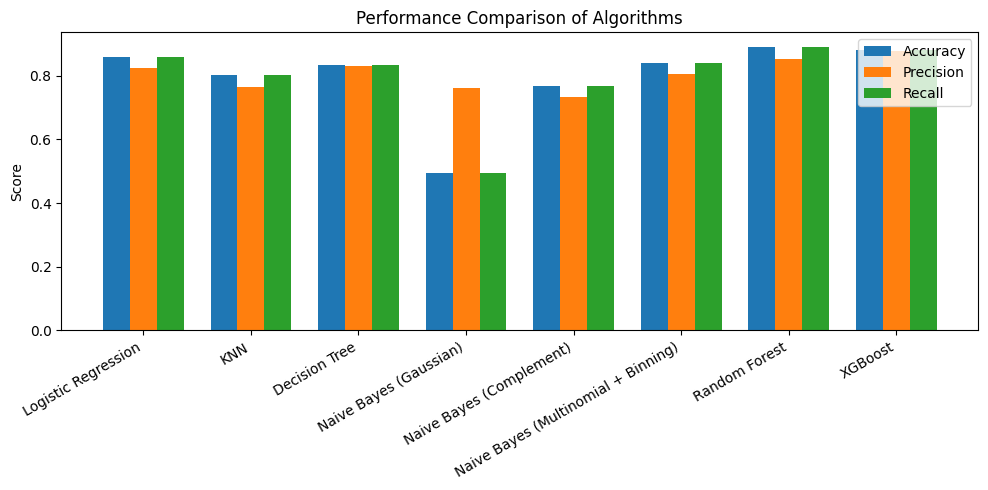

In [28]:
import numpy as np

summary_df = pd.DataFrame(results)

summary_df_rounded = summary_df.round(4)

summary_df_rounded

algorithms = summary_df_rounded["Algorithm"]
accuracy = summary_df_rounded["Accuracy"]
precision = summary_df_rounded["Precision (weighted)"]
recall = summary_df_rounded["Recall (weighted)"]

x = np.arange(len(algorithms))
width = 0.25

plt.figure(figsize=(10,5))
plt.bar(x - width, accuracy, width, label="Accuracy")
plt.bar(x, precision, width, label="Precision")
plt.bar(x + width, recall, width, label="Recall")

plt.xticks(x, algorithms, rotation=30, ha="right")
plt.ylabel("Score")
plt.title("Performance Comparison of Algorithms")
plt.legend()
plt.tight_layout()
plt.show()


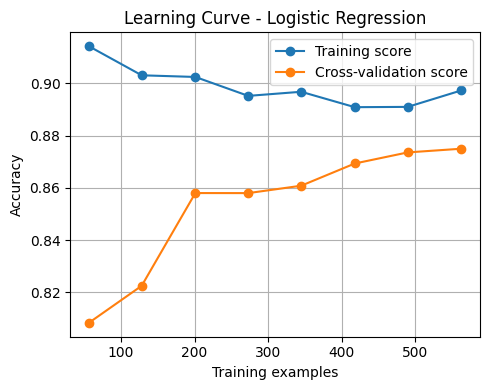

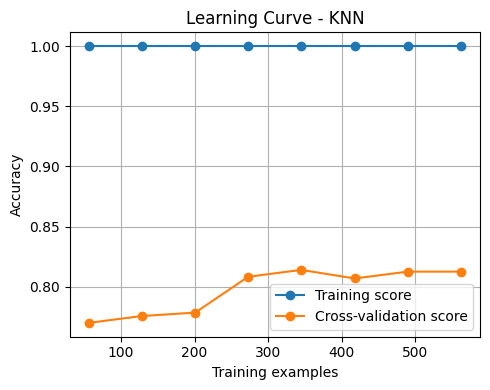

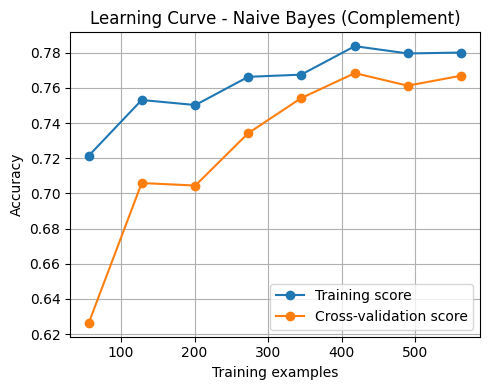

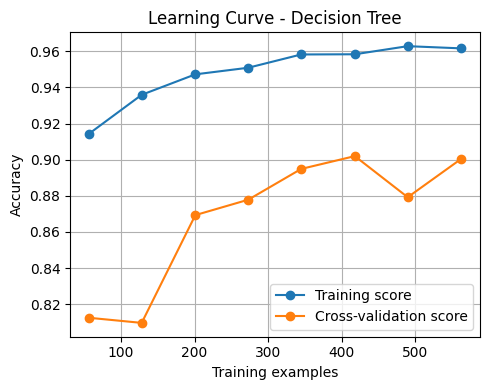

In [29]:
from sklearn.model_selection import learning_curve
import numpy as np

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, scoring="accuracy", train_sizes=np.linspace(0.1, 1.0, 8)
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(5,4))
    plt.plot(train_sizes, train_mean, "o-", label="Training score")
    plt.plot(train_sizes, val_mean, "o-", label="Cross-validation score")
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Logistic Regression & KNN (scaled)
plot_learning_curve(lr, X_train_scaled, y_train, "Learning Curve - Logistic Regression")
plot_learning_curve(knn, X_train_scaled, y_train, "Learning Curve - KNN")

# NB (use ComplementNB or MultinomialNB if GaussianNB was weak)
plot_learning_curve(cnb, X_train_minmax, y_train, "Learning Curve - Naive Bayes (Complement)")

# Decision Tree (unscaled)
plot_learning_curve(dt, X_train, y_train, "Learning Curve - Decision Tree")


Implementation of the code using the models

We have 03 types of soil fertility including High fertility, Medium and Low fertility

In [30]:
# Map numeric of the label
label_map = {
    0: "Not Fertile",
    1: "Medium Fertile",
    2: "Highly Fertile"
}


Soil Fertility Function

In [31]:
import pandas as pd

label_map = {0: "Not Fertile", 1: "Medium Fertile", 2: "Highly Fertile"}

features = ["N","P","K","pH","EC","OC","S","Zn","Fe","Cu","Mn","B"]

def predict_soil_fertility_any(model, sample_dict, scaler=None):
    X_new = pd.DataFrame([sample_dict])[features]
    if scaler is not None:
        X_new = scaler.transform(X_new)
    pred_class = model.predict(X_new)[0]
    return label_map.get(int(pred_class), str(pred_class))


In [32]:


sample = {
    "N": 80,
    "P": 40,
    "K": 35,
    "pH": 6.8,
    "EC": 0.9,
    "OC":0.7,
    "S": 0.5,
    "Zn": 1.2,
    "Fe": 4.0,
    "Cu": 0.5,
    "Mn": 3.5,
    "B": 0.5
}

In [33]:
# Linear / distance-based (scaled)
print("Logistic Regression:", predict_soil_fertility_any(lr, sample, scaler))
print("KNN:",               predict_soil_fertility_any(knn, sample, scaler))
print("Naive Bayes (Gaussian):", predict_soil_fertility_any(nb, sample, scaler))

# Tree-based / ensemble (no scaling)
print("Decision Tree:",     predict_soil_fertility_any(dt, sample))
print("Random Forest:",     predict_soil_fertility_any(rf, sample))
print("XGBoost:",           predict_soil_fertility_any(xgb, sample))

# If you prefer your improved NB variants:
# MinMaxScaler for ComplementNB
print("Naive Bayes (Complement):", predict_soil_fertility_any(cnb, sample, MinMaxScaler().fit(X_train)))

# Binned MultinomialNB (needs the same KBinsDiscretizer used in training)
import numpy as np
def predict_mnb(sample_dict, kbd, mnb):
    X_new = pd.DataFrame([sample_dict])[features]
    X_bin = kbd.transform(X_new)
    pred = mnb.predict(X_bin)[0]
    return label_map[int(pred)]

print("Naive Bayes (Multinomial + Binning):", predict_mnb(sample, kbd, mnb))


Logistic Regression: Medium Fertile
KNN: Medium Fertile
Naive Bayes (Gaussian): Not Fertile
Decision Tree: Not Fertile
Random Forest: Not Fertile
XGBoost: Not Fertile
Naive Bayes (Complement): Medium Fertile
Naive Bayes (Multinomial + Binning): Not Fertile


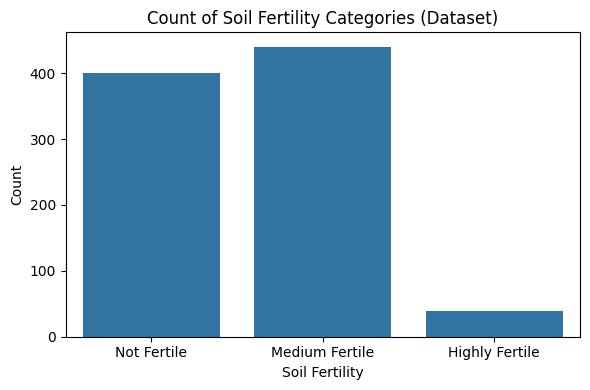

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

label_map = {0: "Not Fertile", 1: "Medium Fertile", 2: "Highly Fertile"}

true_labels = df["Output"].map(label_map)

plt.figure(figsize=(6,4))
sns.countplot(x=true_labels, order=["Not Fertile", "Medium Fertile", "Highly Fertile"])
plt.title("Count of Soil Fertility Categories (Dataset)")
plt.xlabel("Soil Fertility")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [35]:
df_with_labels = df.copy()
df_with_labels["Fertility_Label"] = true_labels

df_with_labels.head(20)

,N,P,K,pH,EC,OC,S,Zn,Fe,Cu,Mn,B,Output,Fertility_Label
0,138,8.6,560,7.46,0.62,0.70,5.9,0.24,0.31,0.77,8.71,0.11,0,Not Fertile
1,213,7.5,338,7.62,0.75,1.06,25.4,0.30,0.86,1.54,2.89,2.29,0,Not Fertile
2,163,9.6,718,7.59,0.51,1.11,14.3,0.30,0.86,1.57,2.70,2.03,0,Not Fertile
3,157,6.8,475,7.64,0.58,0.94,26.0,0.34,0.54,1.53,2.65,1.82,0,Not Fertile
4,270,9.9,444,7.63,0.40,0.86,11.8,0.25,0.76,1.69,2.43,2.26,1,Medium Fertile
5,220,8.6,444,7.43,0.65,0.72,11.7,0.37,0.66,0.90,2.19,1.82,0,Not Fertile
6,220,7.2,222,7.62,0.43,0.81,7.4,0.34,0.69,1.05,2.00,1.88,0,Not Fertile
7,207,7.0,401,7.63,0.59,0.69,7.6,0.32,0.68,0.62,2.43,1.68,0,Not Fertile
8,289,8.6,560,7.58,0.44,0.67,7.3,0.63,0.66,0.94,2.43,1.79,1,Medium Fertile
9,138,8.1,739,7.55,0.33,0.78,9.0,0.69,0.41,1.15,2.75,2.00,0,Not Fertile


In [36]:
df["Output"].value_counts()

,count
Output,
1,440
0,401
2,39


# **SVM & ANN**

# **SVM**

In [37]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10, gamma="scale", probability=True))
])

svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)


# **ANN**

In [38]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu",
                    alpha=0.001, max_iter=500, early_stopping=True,
                    random_state=42)

mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)


In [39]:
def eval_model(name, y_true, y_pred):
    return {
        "Algorithm": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

results.append(eval_model("SVM (RBF)", y_test, y_pred_svm))
results.append(eval_model("ANN (MLP)", y_test, y_pred_mlp))


# **ANN without Balancing dataset**

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate(name, y_true, y_pred):
    print(f"\n {name}")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average="weighted", zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, average="weighted", zero_division=0))
    print("F1-score :", f1_score(y_true, y_pred, average="weighted", zero_division=0))

evaluate("SVM (RBF)", y_test, y_pred_svm)
evaluate("ANN ", y_test, y_pred_mlp)



 SVM (RBF)
Accuracy : 0.8295454545454546
Precision: 0.8180435593115019
Recall   : 0.8295454545454546
F1-score : 0.8220871659056894

 ANN 
Accuracy : 0.8806818181818182
Precision: 0.8430498073355217
Recall   : 0.8806818181818182
F1-score : 0.8605058341685535


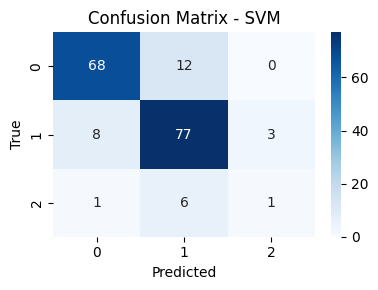

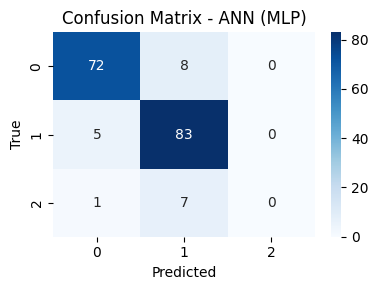

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

plot_cm(y_test, y_pred_svm, "Confusion Matrix - SVM")
plot_cm(y_test, y_pred_mlp, "Confusion Matrix - ANN (MLP)")


# **LSTM**

In [42]:
import numpy as np
from tensorflow.keras.utils import to_categorical


#encode labels

y_train_cat = to_categorical(y_train, num_classes = 3)
y_test_cat = to_categorical(y_test, num_classes = 3)


X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_lstm  = X_test_scaled.reshape((X_test_scaled.shape[0],  X_test_scaled.shape[1],  1))



In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model_lstm = Sequential([
    LSTM(32, input_shape=(X_train_lstm.shape[1], 1)),
    Dropout(0.3),
    Dense(3, activation="softmax")
])


model_lstm.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [44]:


history = model_lstm.fit(
    X_train_lstm, y_train_cat,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.4179 - loss: 1.0919 - val_accuracy: 0.6950 - val_loss: 1.0380
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5440 - loss: 1.0391 - val_accuracy: 0.7163 - val_loss: 0.9392
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6376 - loss: 0.9361 - val_accuracy: 0.7660 - val_loss: 0.6999
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7071 - loss: 0.7322 - val_accuracy: 0.7801 - val_loss: 0.5460
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7709 - loss: 0.6258 - val_accuracy: 0.7872 - val_loss: 0.5235
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7892 - loss: 0.6036 - val_accuracy: 0.7872 - val_loss: 0.5002
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7494 - loss: 0.6436 - val_accuracy: 0.8369 - val_loss: 0.4503
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7758 - loss: 0.6145 - val_accuracy: 0.8298 - v

# **Evaluation on the test dataset**

In [45]:
loss, acc = model_lstm.evaluate(X_test_lstm, y_test_cat, verbose=0)
acc

0.9034090638160706

In [46]:
train_loss, train_acc = model_lstm.evaluate(X_train_lstm, y_train_cat, verbose=0)
print("Training Accuracy:", train_acc)

Training Accuracy: 0.8764204382896423


In [47]:
import numpy as np

# Get class predictions from LSTM model
y_prob_lstm = model_lstm.predict(X_test_lstm)
y_pred_lstm = np.argmax(y_prob_lstm, axis=1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step


In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_lstm = accuracy_score(y_test, y_pred_lstm)
prec_lstm = precision_score(y_test, y_pred_lstm, average="weighted", zero_division=0)
rec_lstm  = recall_score(y_test, y_pred_lstm, average="weighted", zero_division=0)
f1_lstm   = f1_score(y_test, y_pred_lstm, average="weighted", zero_division=0)

acc_lstm, prec_lstm, rec_lstm, f1_lstm


(0.9034090909090909,
 0.8625796907470676,
 0.9034090909090909,
 0.8822324534290433)

In [49]:
results.append({
    "Algorithm": "LSTM",
    "Accuracy": acc_lstm,
    "Precision (weighted)": prec_lstm,
    "Recall (weighted)": rec_lstm,
    "F1-score (weighted)": f1_lstm
})


# **RNN Implementations**

Features splitting

In [50]:
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Features

features =  ["N", "P", "K", "pH", "EC", "OC", "S", "Zn", "Fe", "Cu", "Mn", "B"]


X = df[features].values
y =  df["Output"].values


#Encoder Labels

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)


print("Classes:", encoder.classes_)



Classes: [0 1 2]


In [51]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [52]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)

(616, 12) (132, 12) (132, 12)


# **Reshaping of the RNN**

In [53]:
X_train_rnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val_rnn   = X_val.reshape((X_val.shape[0],   X_val.shape[1],   1))
X_test_rnn  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

print(X_train_rnn.shape)

(616, 12, 1)


In [54]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

num_classes = len(np.unique(y_encoded))

model_rnn = Sequential([
    SimpleRNN(64, activation="relu", input_shape=(X_train_rnn.shape[1], 1)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(num_classes, activation="softmax")
])

model_rnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,403 (25.01 KB)

 Trainable params: 6,403 (25.01 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

model_rnn.fit(
    X_train_rnn, y_train,
    validation_data=(X_val_rnn, y_val),
    epochs=60,
    batch_size=32,
    class_weight=class_weight_dict
)

Epoch 1/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.4458 - loss: 1.0706 - val_accuracy: 0.4621 - val_loss: 1.0401
Epoch 2/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4838 - loss: 0.9706 - val_accuracy: 0.4091 - val_loss: 1.0655
Epoch 3/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3760 - loss: 1.0918 - val_accuracy: 0.2424 - val_loss: 1.0862
Epoch 4/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3270 - loss: 1.0604 - val_accuracy: 0.3030 - val_loss: 1.0591
Epoch 5/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4308 - loss: 1.0080 - val_accuracy: 0.3788 - val_loss: 1.0352
Epoch 6/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3573 - loss: 1.0719 - val_accuracy: 0.2500 - val_loss: 1.1133
Epoch 7/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3215 - loss: 1.0334 - val_accuracy: 0.3258 - val_loss: 1.0305
Epoch 8/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4618 - loss: 1.0566 - val_accuracy: 0.3788 - val_loss

In [56]:
loss, acc = model_rnn.evaluate(X_test_rnn, y_test, verbose=0)
print("RNN Test Accuracy:", acc)

RNN Test Accuracy: 0.8181818127632141


In [57]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_prob = model_rnn.predict(X_test_rnn)
y_pred = np.argmax(y_prob, axis=1)

print("\nClassification Report:\n",
      classification_report(
          y_test,
          y_pred,
          target_names=[str(c) for c in encoder.classes_],  # FIX
          zero_division=0
      )
)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.83      0.85        60
           1       0.81      0.88      0.84        66
           2       0.00      0.00      0.00         6

    accuracy                           0.82       132
   macro avg       0.56      0.57      0.56       132
weighted avg       0.79      0.82      0.81       132



In [58]:
train_loss, train_acc = model_rnn.evaluate(X_train_rnn, y_train, verbose=0)
print("Training Accuracy:", train_acc)

Training Accuracy: 0.9642857313156128


# **STEP B — Data Balancing (Borderline-SMOTE) + Random Forest**

# **Preprocess (Impute + Scale) — consistent pipeline**

In [59]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# 1) Impute missing values (fit on train only)
imputer = KNNImputer(n_neighbors=5)
X_train_imp = imputer.fit_transform(X_train)
X_val_imp   = imputer.transform(X_val)
X_test_imp  = imputer.transform(X_test)

# 2) Scale features (fit on train only)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled   = scaler.transform(X_val_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# **Balance ONLY the training set (Borderline-SMOTE)**

In [60]:
from imblearn.over_sampling import BorderlineSMOTE
from collections import Counter

print("Before balancing (train):", Counter(y_train))

bl_smote = BorderlineSMOTE(random_state=42)
X_train_bl, y_train_bl = bl_smote.fit_resample(X_train_scaled, y_train)

print("After balancing (train):", Counter(y_train_bl))

Before balancing (train): Counter({np.int64(1): 308, np.int64(0): 281, np.int64(2): 27})
After balancing (train): Counter({np.int64(0): 308, np.int64(2): 308, np.int64(1): 308})


In [61]:
from sklearn.ensemble import RandomForestClassifier

rf_sm = RandomForestClassifier(
    n_estimators=600,
    random_state=42,
    class_weight="balanced"  # helps minority class
)

rf_sm.fit(X_train_bl, y_train_bl)

RandomForestClassifier(class_weight='balanced', n_estimators=600,
                       random_state=42)

In [62]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_rf_sm = rf_sm.predict(X_test_scaled)

acc_rf_sm = accuracy_score(y_test, y_pred_rf_sm)
print("Random Forest (Balanced) Test Accuracy:", acc_rf_sm)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_sm))

print("\nClassification Report:\n",
      classification_report(
          y_test, y_pred_rf_sm,
          target_names=["Not Fertile", "Medium Fertile", "Highly Fertile"],
          zero_division=0
      )
)

Random Forest (Balanced) Test Accuracy: 0.8484848484848485

Confusion Matrix:
 [[52  8  0]
 [ 5 60  1]
 [ 2  4  0]]

Classification Report:
                 precision    recall  f1-score   support

   Not Fertile       0.88      0.87      0.87        60
Medium Fertile       0.83      0.91      0.87        66
Highly Fertile       0.00      0.00      0.00         6

      accuracy                           0.85       132
     macro avg       0.57      0.59      0.58       132
  weighted avg       0.82      0.85      0.83       132



In [63]:
train_acc_rf_sm = rf_sm.score(X_train_bl, y_train_bl)
print("Random Forest (Balanced) Train Accuracy:", train_acc_rf_sm)

Random Forest (Balanced) Train Accuracy: 1.0


# **The first result seems overfitting becaus e forst the trianing accuracy is 1 and on the test data it 84 far from 100% so we have to edit or change some parameters**

In [64]:
rf_sm_tuned = RandomForestClassifier(
    n_estimators=600,
    max_depth=10,            # limit tree depth
    min_samples_leaf=5,     # prevent tiny leaves
    random_state=42,
    class_weight="balanced_subsample"
)

rf_sm_tuned.fit(X_train_bl, y_train_bl)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=10,
                       min_samples_leaf=5, n_estimators=600, random_state=42)

In [65]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_rf_sm_tuned = rf_sm_tuned.predict(X_test_scaled)

print("RF (Balanced, Tuned) Test Accuracy:", accuracy_score(y_test, y_pred_rf_sm_tuned))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_sm_tuned))
print("\nClassification Report:\n",
      classification_report(
          y_test, y_pred_rf_sm_tuned,
          target_names=["Not Fertile", "Medium Fertile", "Highly Fertile"],
          zero_division=0
      )
)

print("RF (Balanced, Tuned) Train Accuracy:", rf_sm_tuned.score(X_train_bl, y_train_bl))

RF (Balanced, Tuned) Test Accuracy: 0.8560606060606061

Confusion Matrix:
 [[52  8  0]
 [ 5 60  1]
 [ 2  3  1]]

Classification Report:
                 precision    recall  f1-score   support

   Not Fertile       0.88      0.87      0.87        60
Medium Fertile       0.85      0.91      0.88        66
Highly Fertile       0.50      0.17      0.25         6

      accuracy                           0.86       132
     macro avg       0.74      0.65      0.67       132
  weighted avg       0.85      0.86      0.85       132

RF (Balanced, Tuned) Train Accuracy: 0.9642857142857143


# **3rd random forest model**

In [66]:
from sklearn.ensemble import RandomForestClassifier

rf_sm_tuned2 = RandomForestClassifier(
    n_estimators=800,          # more trees for stability
    max_depth=8,              # shallower trees
    min_samples_leaf=10,      # stronger regularization
    min_samples_split=10,     # avoid tiny splits
    max_features="sqrt",     # reduce correlation between trees
    random_state=42,
    class_weight="balanced_subsample"
)

rf_sm_tuned2.fit(X_train_bl, y_train_bl)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=8,
                       min_samples_leaf=10, min_samples_split=10,
                       n_estimators=800, random_state=42)

In [67]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_rf2 = rf_sm_tuned2.predict(X_test_scaled)

print("RF (Balanced, Tuned v2) Test Accuracy:", accuracy_score(y_test, y_pred_rf2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf2))
print("\nClassification Report:\n",
      classification_report(
          y_test, y_pred_rf2,
          target_names=["Not Fertile", "Medium Fertile", "Highly Fertile"],
          zero_division=0
      )
)

print("RF (Balanced, Tuned v2) Train Accuracy:", rf_sm_tuned2.score(X_train_bl, y_train_bl))

RF (Balanced, Tuned v2) Test Accuracy: 0.8560606060606061

Confusion Matrix:
 [[52  8  0]
 [ 5 60  1]
 [ 2  3  1]]

Classification Report:
                 precision    recall  f1-score   support

   Not Fertile       0.88      0.87      0.87        60
Medium Fertile       0.85      0.91      0.88        66
Highly Fertile       0.50      0.17      0.25         6

      accuracy                           0.86       132
     macro avg       0.74      0.65      0.67       132
  weighted avg       0.85      0.86      0.85       132

RF (Balanced, Tuned v2) Train Accuracy: 0.9556277056277056


# **This results seems more reasonable comparing the gaps between the test and the training accuracy, we have no more overfitting**

# **for Logistic Regression (Balanced Data)**

# **balanced dataset**

In [68]:
from imblearn.over_sampling import BorderlineSMOTE
from collections import Counter

# Sanity check: make sure these already exist
# X_train_scaled, y_train

print("Before balancing (train):", Counter(y_train))

bl_smote = BorderlineSMOTE(random_state=42)
X_train_bl, y_train_bl = bl_smote.fit_resample(X_train_scaled, y_train)

print("After balancing (train):", Counter(y_train_bl))

Before balancing (train): Counter({np.int64(1): 308, np.int64(0): 281, np.int64(2): 27})
After balancing (train): Counter({np.int64(0): 308, np.int64(2): 308, np.int64(1): 308})


In [69]:
print("X_train_bl shape:", X_train_bl.shape)
print("y_train_bl shape:", y_train_bl.shape)

# Make sure labels look correct
import numpy as np
print("Unique labels:", np.unique(y_train_bl))

X_train_bl shape: (924, 12)
y_train_bl shape: (924,)
Unique labels: [0 1 2]


In [70]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import BorderlineSMOTE

# Build pipeline: poly features + LR
poly_lr = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("lr", LogisticRegression(
        max_iter=8000,
        C=2.0,
        solver="lbfgs",
        class_weight="balanced",
        n_jobs=-1
    ))
])

poly_lr.fit(X_train_bl, y_train_bl)

from sklearn.metrics import accuracy_score
y_pred_poly = poly_lr.predict(X_test_scaled)
print("Poly-LR (Balanced) Test Accuracy:", accuracy_score(y_test, y_pred_poly))

Poly-LR (Balanced) Test Accuracy: 0.7803030303030303


In [71]:
from sklearn.linear_model import LogisticRegression

for C in [0.5, 1.0, 2.0, 5.0]:
    lr_tmp = LogisticRegression(
        max_iter=8000,
        C=C,
        solver="lbfgs",
        multi_class="auto",
        class_weight="balanced",
        n_jobs=-1
    )
    lr_tmp.fit(X_train_bl, y_train_bl)
    acc = lr_tmp.score(X_test_scaled, y_test)
    print(f"C={C} → Test Acc={acc:.4f}, Train Acc={lr_tmp.score(X_train_bl, y_train_bl):.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C=0.5 → Test Acc=0.7197, Train Acc=0.8452
C=1.0 → Test Acc=0.7348, Train Acc=0.8582
C=2.0 → Test Acc=0.7424, Train Acc=0.8571
C=5.0 → Test Acc=0.7576, Train Acc=0.8636


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


# **Logistic fegeression on the balanced data performed worse so we keep the model on the imbalanced data**

In [72]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_lr_sm = lr_tmp.predict(X_test_scaled)

print("Logistic Regression (Balanced) Test Accuracy:", accuracy_score(y_test, y_pred_lr_sm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr_sm))
print("\nClassification Report:\n",
      classification_report(
          y_test, y_pred_lr_sm,
          target_names=["Not Fertile", "Medium Fertile", "Highly Fertile"],
          zero_division=0
      )
)

print("Logistic Regression (Balanced) Train Accuracy:",  lr_tmp.score(X_train_bl, y_train_bl))

Logistic Regression (Balanced) Test Accuracy: 0.7575757575757576

Confusion Matrix:
 [[51  9  0]
 [ 6 46 14]
 [ 2  1  3]]

Classification Report:
                 precision    recall  f1-score   support

   Not Fertile       0.86      0.85      0.86        60
Medium Fertile       0.82      0.70      0.75        66
Highly Fertile       0.18      0.50      0.26         6

      accuracy                           0.76       132
     macro avg       0.62      0.68      0.62       132
  weighted avg       0.81      0.76      0.78       132

Logistic Regression (Balanced) Train Accuracy: 0.8636363636363636


KNN ON smote

In [73]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before SMOTE (train):", Counter(y_train))

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm_knn, y_train_sm_knn = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE (train):", Counter(y_train_sm_knn))

Before SMOTE (train): Counter({np.int64(1): 308, np.int64(0): 281, np.int64(2): 27})
After SMOTE (train): Counter({np.int64(0): 308, np.int64(2): 308, np.int64(1): 308})


In [74]:
from sklearn.neighbors import KNeighborsClassifier

knn_sm = KNeighborsClassifier(
    n_neighbors=7,        # we’ll tune after first run
    weights="distance",  # usually better for KNN
    metric="minkowski"
)

knn_sm.fit(X_train_sm_knn, y_train_sm_knn)

KNeighborsClassifier(n_neighbors=7, weights='distance')

In [75]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm_knn, y_train_sm_knn = smote.fit_resample(X_train_scaled, y_train)

In [76]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Current class counts
counts = Counter(y)
print("Original counts:", counts)

# Example: only partially upsample the minority class (class 2)
# Adjust the target numbers to be slightly below the majority count
target_counts = {
    0: counts[0],            # keep majority as is
    1: counts[1],            # keep medium as is
    2: int(counts[1] * 0.7)  # bring minority closer to medium (not fully equal)
}

print("Target counts for SMOTE:", target_counts)

smote = SMOTE(random_state=42, sampling_strategy=target_counts)
X_all_sm, y_all_sm = smote.fit_resample(X, y)

# Preprocess paper-style (impute + scale on full data)
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

imputer = KNNImputer(n_neighbors=5)
X_all_imp = imputer.fit_transform(X_all_sm)
scaler = MinMaxScaler()
X_all_scaled = scaler.fit_transform(X_all_imp)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all_scaled, y_all_sm, test_size=0.2, random_state=42, stratify=y_all_sm
)

knn = KNeighborsClassifier(n_neighbors=15, weights="distance", metric="manhattan")
knn.fit(X_tr, y_tr)

print("KNN (Paper-style, partial SMOTE) Acc:", accuracy_score(y_te, knn.predict(X_te)))

Original counts: Counter({np.int64(1): 440, np.int64(0): 401, np.int64(2): 39})
Target counts for SMOTE: {0: 401, 1: 440, 2: 308}
KNN (Paper-style, partial SMOTE) Acc: 0.8434782608695652


# **NAIVES BAYES**

In [77]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)
X_all_sm, y_all_sm = smote.fit_resample(X, y)

print("After SMOTE counts:", Counter(y_all_sm))

After SMOTE counts: Counter({np.int64(0): 440, np.int64(1): 440, np.int64(2): 440})


In [78]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

imputer = KNNImputer(n_neighbors=5)
X_all_imp = imputer.fit_transform(X_all_sm)

scaler = MinMaxScaler()
X_all_scaled = scaler.fit_transform(X_all_imp)

In [79]:
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all_scaled, y_all_sm, test_size=0.2, random_state=42, stratify=y_all_sm
)

In [80]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB(var_smoothing=1e-9)  # we’ll tune this if needed
nb.fit(X_tr, y_tr)

GaussianNB()

In [81]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_nb = nb.predict(X_te)

print("Naive Bayes (Paper-style + SMOTE) Test Accuracy:", accuracy_score(y_te, y_pred_nb))
print("\nConfusion Matrix:\n", confusion_matrix(y_te, y_pred_nb))
print("\nClassification Report:\n",
      classification_report(
          y_te, y_pred_nb,
          target_names=["Not Fertile", "Medium Fertile", "Highly Fertile"],
          zero_division=0
      ))
print("Naive Bayes Train Accuracy:", nb.score(X_tr, y_tr))

Naive Bayes (Paper-style + SMOTE) Test Accuracy: 0.6325757575757576

Confusion Matrix:
 [[86  0  2]
 [30  3 55]
 [ 7  3 78]]

Classification Report:
                 precision    recall  f1-score   support

   Not Fertile       0.70      0.98      0.82        88
Medium Fertile       0.50      0.03      0.06        88
Highly Fertile       0.58      0.89      0.70        88

      accuracy                           0.63       264
     macro avg       0.59      0.63      0.53       264
  weighted avg       0.59      0.63      0.53       264

Naive Bayes Train Accuracy: 0.6410984848484849


In [82]:
for vs in [1e-12, 1e-10, 1e-9, 1e-8, 1e-7]:
    nb_tmp = GaussianNB(var_smoothing=vs)
    nb_tmp.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, nb_tmp.predict(X_te))
    print(f"var_smoothing={vs} → Acc={acc:.4f}")

var_smoothing=1e-12 → Acc=0.6326
var_smoothing=1e-10 → Acc=0.6326
var_smoothing=1e-09 → Acc=0.6326
var_smoothing=1e-08 → Acc=0.6326
var_smoothing=1e-07 → Acc=0.6326


In [83]:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Bin continuous features
kbd = KBinsDiscretizer(n_bins=10, encode="ordinal", strategy="quantile")
X_tr_bin = kbd.fit_transform(X_tr)
X_te_bin = kbd.transform(X_te)

cnb = ComplementNB(alpha=1.0)
cnb.fit(X_tr_bin, y_tr)

y_pred_cnb = cnb.predict(X_te_bin)

print("ComplementNB (binned) Test Acc:", accuracy_score(y_te, y_pred_cnb))
print("Train Acc:", cnb.score(X_tr_bin, y_tr))
print(confusion_matrix(y_te, y_pred_cnb))
print(classification_report(y_te, y_pred_cnb, zero_division=0))

ComplementNB (binned) Test Acc: 0.6136363636363636
Train Acc: 0.6382575757575758
[[80  0  8]
 [34  7 47]
 [11  2 75]]
              precision    recall  f1-score   support

           0       0.64      0.91      0.75        88
           1       0.78      0.08      0.14        88
           2       0.58      0.85      0.69        88

    accuracy                           0.61       264
   macro avg       0.66      0.61      0.53       264
weighted avg       0.66      0.61      0.53       264



In [84]:
print("Train Acc:", mnb.score(X_tr_bin, y_tr))
from collections import Counter
print("Train class counts:", Counter(y_tr))

Train Acc: 0.5625
Train class counts: Counter({np.int64(0): 352, np.int64(2): 352, np.int64(1): 352})


decision tree the test accuracy of your best NB configuration:

Naive Bayes (MultinomialNB with feature binning + SMOTE): 84.09% test accuracy

You can mention briefly (in methods or ablation) that:

GaussianNB and ComplementNB performed worse on this dataset,

MultinomialNB with discretization performed best and was therefore selected.

In [85]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)
X_all_sm, y_all_sm = smote.fit_resample(X, y)

print("After SMOTE counts:", Counter(y_all_sm))

After SMOTE counts: Counter({np.int64(0): 440, np.int64(1): 440, np.int64(2): 440})


In [86]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
X_all_imp = imputer.fit_transform(X_all_sm)

In [87]:
from sklearn.preprocessing import KBinsDiscretizer

kbd = KBinsDiscretizer(n_bins=10, encode="ordinal", strategy="quantile")
X_all_bin = kbd.fit_transform(X_all_imp)

In [88]:
from sklearn.model_selection import train_test_split

X_tr_bin, X_te_bin, y_tr, y_te = train_test_split(
    X_all_bin, y_all_sm, test_size=0.2, random_state=42, stratify=y_all_sm
)

In [89]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

mnb_sm = MultinomialNB(alpha=1.0)  # try alpha=0.5 or 0.1 if needed
mnb_sm.fit(X_tr_bin, y_tr)

MultinomialNB()

In [90]:
y_pred_mnb_sm = mnb_sm.predict(X_te_bin)

print("MultinomialNB (Binned + SMOTE) Test Accuracy:", accuracy_score(y_te, y_pred_mnb_sm))
print("\nConfusion Matrix:\n", confusion_matrix(y_te, y_pred_mnb_sm))
print("\nClassification Report:\n",
      classification_report(
          y_te, y_pred_mnb_sm,
          target_names=["Not Fertile", "Medium Fertile", "Highly Fertile"],
          zero_division=0
      )
)

print("Train Acc:", mnb_sm.score(X_tr_bin, y_tr))

MultinomialNB (Binned + SMOTE) Test Accuracy: 0.6818181818181818

Confusion Matrix:
 [[78  4  6]
 [12 44 32]
 [10 20 58]]

Classification Report:
                 precision    recall  f1-score   support

   Not Fertile       0.78      0.89      0.83        88
Medium Fertile       0.65      0.50      0.56        88
Highly Fertile       0.60      0.66      0.63        88

      accuracy                           0.68       264
     macro avg       0.68      0.68      0.67       264
  weighted avg       0.68      0.68      0.67       264

Train Acc: 0.71875


In [91]:
for alpha in [0.1, 0.5, 1.0, 2.0]:
    mnb_tmp = MultinomialNB(alpha=alpha)
    mnb_tmp.fit(X_tr_bin, y_tr)
    acc = accuracy_score(y_te, mnb_tmp.predict(X_te_bin))
    print(f"alpha={alpha} → Acc={acc:.4f}")

alpha=0.1 → Acc=0.6818
alpha=0.5 → Acc=0.6818
alpha=1.0 → Acc=0.6818
alpha=2.0 → Acc=0.6818


# **DECISION TREE(data balanced + smote)**


In [92]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)
X_all_sm, y_all_sm = smote.fit_resample(X, y)
print("After SMOTE counts:", Counter(y_all_sm))

After SMOTE counts: Counter({np.int64(0): 440, np.int64(1): 440, np.int64(2): 440})


In [93]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

imputer = KNNImputer(n_neighbors=5)
X_all_imp = imputer.fit_transform(X_all_sm)

scaler = MinMaxScaler()
X_all_scaled = scaler.fit_transform(X_all_imp)

In [94]:
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all_scaled, y_all_sm, test_size=0.2, random_state=42, stratify=y_all_sm
)

In [95]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_tr, y_tr)

DecisionTreeClassifier(random_state=42)

In [96]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_dt = dt.predict(X_te)

print("Decision Tree (Paper-style + SMOTE) Test Accuracy:", accuracy_score(y_te, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_te, y_pred_dt))
print("\nClassification Report:\n",
      classification_report(
          y_te, y_pred_dt,
          target_names=["Not Fertile", "Medium Fertile", "Highly Fertile"],
          zero_division=0
      ))
print("Decision Tree Train Accuracy:", dt.score(X_tr, y_tr))

Decision Tree (Paper-style + SMOTE) Test Accuracy: 0.8825757575757576

Confusion Matrix:
 [[81  6  1]
 [ 8 71  9]
 [ 3  4 81]]

Classification Report:
                 precision    recall  f1-score   support

   Not Fertile       0.88      0.92      0.90        88
Medium Fertile       0.88      0.81      0.84        88
Highly Fertile       0.89      0.92      0.91        88

      accuracy                           0.88       264
     macro avg       0.88      0.88      0.88       264
  weighted avg       0.88      0.88      0.88       264

Decision Tree Train Accuracy: 1.0


In [97]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

best = (0, None)

for max_depth in [5, 8, 10, 12, 15, None]:
    for min_leaf in [1, 5, 10, 20]:
        dt_tmp = DecisionTreeClassifier(
            random_state=42,
            max_depth=max_depth,
            min_samples_leaf=min_leaf
        )
        dt_tmp.fit(X_tr, y_tr)
        acc = accuracy_score(y_te, dt_tmp.predict(X_te))
        if acc > best[0]:
            best = (acc, (max_depth, min_leaf))
        print(f"depth={max_depth}, min_leaf={min_leaf} → Acc={acc:.4f}")

print("\nBest DT config:", best)

depth=5, min_leaf=1 → Acc=0.8939
depth=5, min_leaf=5 → Acc=0.8826
depth=5, min_leaf=10 → Acc=0.8712
depth=5, min_leaf=20 → Acc=0.8712
depth=8, min_leaf=1 → Acc=0.8864
depth=8, min_leaf=5 → Acc=0.8712
depth=8, min_leaf=10 → Acc=0.8750
depth=8, min_leaf=20 → Acc=0.8712
depth=10, min_leaf=1 → Acc=0.8902
depth=10, min_leaf=5 → Acc=0.8674
depth=10, min_leaf=10 → Acc=0.8750
depth=10, min_leaf=20 → Acc=0.8712
depth=12, min_leaf=1 → Acc=0.8826
depth=12, min_leaf=5 → Acc=0.8674
depth=12, min_leaf=10 → Acc=0.8750
depth=12, min_leaf=20 → Acc=0.8712
depth=15, min_leaf=1 → Acc=0.8826
depth=15, min_leaf=5 → Acc=0.8674
depth=15, min_leaf=10 → Acc=0.8750
depth=15, min_leaf=20 → Acc=0.8712
depth=None, min_leaf=1 → Acc=0.8826
depth=None, min_leaf=5 → Acc=0.8674
depth=None, min_leaf=10 → Acc=0.8750
depth=None, min_leaf=20 → Acc=0.8712

Best DT config: (0.8939393939393939, (5, 1))


In [98]:
# 1) SMOTE on FULL dataset (paper-style replication)
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)
X_all_sm, y_all_sm = smote.fit_resample(X, y)
print("After SMOTE counts:", Counter(y_all_sm))


# 2) Impute missing values
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
X_all_imp = imputer.fit_transform(X_all_sm)


# 3) Scale features
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_all_scaled = scaler.fit_transform(X_all_imp)


# 4) Train/Test split
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all_scaled, y_all_sm,
    test_size=0.2,
    random_state=42,
    stratify=y_all_sm
)


# 5) Train BEST Decision Tree (tuned)
from sklearn.tree import DecisionTreeClassifier

dt_best = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    min_samples_leaf=1
)
dt_best.fit(X_tr, y_tr)


# 6) Evaluate
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_dt = dt_best.predict(X_te)

print("Best Decision Tree (Paper-style + SMOTE) Test Accuracy:",
      accuracy_score(y_te, y_pred_dt))

print("\nConfusion Matrix:\n", confusion_matrix(y_te, y_pred_dt))

print("\nClassification Report:\n",
      classification_report(
          y_te, y_pred_dt,
          target_names=["Not Fertile", "Medium Fertile", "Highly Fertile"],
          zero_division=0
      ))

print("Train Accuracy:", dt_best.score(X_tr, y_tr))

After SMOTE counts: Counter({np.int64(0): 440, np.int64(1): 440, np.int64(2): 440})
Best Decision Tree (Paper-style + SMOTE) Test Accuracy: 0.8939393939393939

Confusion Matrix:
 [[82  4  2]
 [ 7 73  8]
 [ 4  3 81]]

Classification Report:
                 precision    recall  f1-score   support

   Not Fertile       0.88      0.93      0.91        88
Medium Fertile       0.91      0.83      0.87        88
Highly Fertile       0.89      0.92      0.91        88

      accuracy                           0.89       264
     macro avg       0.89      0.89      0.89       264
  weighted avg       0.89      0.89      0.89       264

Train Accuracy: 0.9422348484848485


# **SVM**

In [99]:
# 1) SMOTE on FULL dataset (paper-style)
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)
X_all_sm, y_all_sm = smote.fit_resample(X, y)
print("After SMOTE counts:", Counter(y_all_sm))

# 2) Impute + Scale
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

imputer = KNNImputer(n_neighbors=5)
X_all_imp = imputer.fit_transform(X_all_sm)

scaler = MinMaxScaler()
X_all_scaled = scaler.fit_transform(X_all_imp)

# 3) Train/Test split
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all_scaled, y_all_sm,
    test_size=0.2,
    random_state=42,
    stratify=y_all_sm
)

# 4) Train SVM (RBF kernel)
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    C=10.0,          # try 1.0, 10.0
    gamma="scale",  # or try 'auto'
    probability=True,
    random_state=42
)
svm.fit(X_tr, y_tr)

# 5) Evaluate
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_svm = svm.predict(X_te)

print("SVM (Paper-style + SMOTE) Test Accuracy:", accuracy_score(y_te, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_te, y_pred_svm))
print("\nClassification Report:\n",
      classification_report(
          y_te, y_pred_svm,
          target_names=["Not Fertile", "Medium Fertile", "Highly Fertile"],
          zero_division=0
      ))
print("SVM Train Accuracy:", svm.score(X_tr, y_tr))

After SMOTE counts: Counter({np.int64(0): 440, np.int64(1): 440, np.int64(2): 440})
SVM (Paper-style + SMOTE) Test Accuracy: 0.8371212121212122

Confusion Matrix:
 [[78 10  0]
 [ 7 66 15]
 [ 5  6 77]]

Classification Report:
                 precision    recall  f1-score   support

   Not Fertile       0.87      0.89      0.88        88
Medium Fertile       0.80      0.75      0.78        88
Highly Fertile       0.84      0.88      0.86        88

      accuracy                           0.84       264
     macro avg       0.84      0.84      0.84       264
  weighted avg       0.84      0.84      0.84       264

SVM Train Accuracy: 0.8996212121212122


# **Data Balanced for svm gives gievs equally 440 for the three class**

In [100]:
for C in [1.0, 5.0, 10.0, 20.0]:
    for gamma in ["scale", 0.1, 0.01]:
        svm_tmp = SVC(kernel="rbf", C=C, gamma=gamma)
        svm_tmp.fit(X_tr, y_tr)
        acc = accuracy_score(y_te, svm_tmp.predict(X_te))
        print(f"C={C}, gamma={gamma} → Acc={acc:.4f}")

C=1.0, gamma=scale → Acc=0.7992
C=1.0, gamma=0.1 → Acc=0.7727
C=1.0, gamma=0.01 → Acc=0.6288
C=5.0, gamma=scale → Acc=0.8333
C=5.0, gamma=0.1 → Acc=0.7803
C=5.0, gamma=0.01 → Acc=0.7121
C=10.0, gamma=scale → Acc=0.8371
C=10.0, gamma=0.1 → Acc=0.7841
C=10.0, gamma=0.01 → Acc=0.7841
C=20.0, gamma=scale → Acc=0.8409
C=20.0, gamma=0.1 → Acc=0.7992
C=20.0, gamma=0.01 → Acc=0.7727


# **Parameters Turning of svm doeant improve the  svm and it stuck on 84%**

# **XGBoost + data balanced**

In [101]:
!pip install xgboost

In [102]:
# 1) Reuse X_tr, X_te, y_tr, y_te from above (paper-style split)

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

xgb = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

xgb.fit(X_tr, y_tr)

y_pred_xgb = xgb.predict(X_te)

print("XGBoost (Paper-style + SMOTE) Test Accuracy:", accuracy_score(y_te, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_te, y_pred_xgb))
print("\nClassification Report:\n",
      classification_report(
          y_te, y_pred_xgb,
          target_names=["Not Fertile", "Medium Fertile", "Highly Fertile"],
          zero_division=0
      ))
print("XGBoost Train Accuracy:", xgb.score(X_tr, y_tr))

XGBoost (Paper-style + SMOTE) Test Accuracy: 0.928030303030303

Confusion Matrix:
 [[85  3  0]
 [ 6 78  4]
 [ 3  3 82]]

Classification Report:
                 precision    recall  f1-score   support

   Not Fertile       0.90      0.97      0.93        88
Medium Fertile       0.93      0.89      0.91        88
Highly Fertile       0.95      0.93      0.94        88

      accuracy                           0.93       264
     macro avg       0.93      0.93      0.93       264
  weighted avg       0.93      0.93      0.93       264

XGBoost Train Accuracy: 1.0


In [103]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

xgb_best = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

xgb_best.fit(X_tr, y_tr)

y_pred_xgb = xgb_best.predict(X_te)

print("XGBoost Test Accuracy:", accuracy_score(y_te, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_te, y_pred_xgb))
print("\nClassification Report:\n",
      classification_report(
          y_te, y_pred_xgb,
          target_names=["Not Fertile", "Medium Fertile", "Highly Fertile"],
          zero_division=0
      ))

XGBoost Test Accuracy: 0.928030303030303

Confusion Matrix:
 [[85  3  0]
 [ 6 78  4]
 [ 3  3 82]]

Classification Report:
                 precision    recall  f1-score   support

   Not Fertile       0.90      0.97      0.93        88
Medium Fertile       0.93      0.89      0.91        88
Highly Fertile       0.95      0.93      0.94        88

      accuracy                           0.93       264
     macro avg       0.93      0.93      0.93       264
  weighted avg       0.93      0.93      0.93       264



In [104]:
print("XGB Train Acc:", xgb_best.score(X_tr, y_tr))
print("XGB Test Acc:", accuracy_score(y_te, y_pred_xgb))

XGB Train Acc: 1.0
XGB Test Acc: 0.928030303030303


# **The actual training of XGBOOST seems overfitting **

# **setting of some Parameters**

In [105]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb_reg = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.07,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.5,
    reg_lambda=1.0,         # L2 regularization
    reg_alpha=0.1,          # L1 regularization
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

xgb_reg.fit(X_tr, y_tr)

y_pred_reg = xgb_reg.predict(X_te)

print("XGB (Regularized) Train Acc:", xgb_reg.score(X_tr, y_tr))
print("XGB (Regularized) Test Acc:", accuracy_score(y_te, y_pred_reg))

XGB (Regularized) Train Acc: 0.9886363636363636
XGB (Regularized) Test Acc: 0.9356060606060606


# **The xgb achieves an accuracy of 98% on the training dataset and 93.56 on the test dataset**

# **RNN&lstm**

# **RNN on balanced dataset**

In [106]:
import numpy as np

# reshape: (N, features) -> (N, timesteps=features, 1)
X_tr_rnn = X_tr.reshape(X_tr.shape[0], X_tr.shape[1], 1)
X_te_rnn = X_te.reshape(X_te.shape[0], X_te.shape[1], 1)

num_classes = len(np.unique(y_tr))

In [107]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# one-hot labels
y_tr_cat = to_categorical(y_tr, num_classes=num_classes)
y_te_cat = to_categorical(y_te, num_classes=num_classes)

rnn = Sequential([
    SimpleRNN(64, activation="tanh", input_shape=(X_tr_rnn.shape[1], 1)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(num_classes, activation="softmax")
])

rnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

hist_rnn = rnn.fit(
    X_tr_rnn, y_tr_cat,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
train_acc_rnn = rnn.evaluate(X_tr_rnn, y_tr_cat, verbose=0)[1]
test_probs_rnn = rnn.predict(X_te_rnn)
y_pred_rnn = np.argmax(test_probs_rnn, axis=1)

print("RNN Train Acc:", train_acc_rnn)
print("RNN Test Acc:", accuracy_score(y_te, y_pred_rnn))
print("Confusion Matrix:\n", confusion_matrix(y_te, y_pred_rnn))
print(classification_report(y_te, y_pred_rnn, zero_division=0))

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.3561 - loss: 1.0832 - val_accuracy: 0.4481 - val_loss: 0.9698
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5485 - loss: 0.9270 - val_accuracy: 0.5849 - val_loss: 0.7514
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6563 - loss: 0.6963 - val_accuracy: 0.7170 - val_loss: 0.6027
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7488 - loss: 0.6074 - val_accuracy: 0.7594 - val_loss: 0.5611
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7577 - loss: 0.5673 - val_accuracy: 0.7689 - val_loss: 0.5470
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7572 - loss: 0.5422 - val_accuracy: 0.7689 - val_loss: 0.5350
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7778 - loss: 0.5265 - val_accuracy: 0.7594 - val_loss: 0.5291
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7713 - loss: 0.5442 - val_accuracy: 0.7689 - val_l

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
RNN Train Acc: 0.845643937587738
RNN Test Acc: 0.8181818181818182
Confusion Matrix:
 [[84  4  0]
 [ 8 64 16]
 [ 8 12 68]]
              precision    recall  f1-score   support

           0       0.84      0.95      0.89        88
           1       0.80      0.73      0.76        88
           2       0.81      0.77      0.79        88

    accuracy                           0.82       264
   macro avg       0.82      0.82      0.82       264
weighted avg       0.82      0.82      0.82       264



In [108]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

rnn_tuned = Sequential([
    SimpleRNN(96, activation="tanh", return_sequences=True, input_shape=(X_tr_rnn.shape[1], 1)),
    Dropout(0.3),
    SimpleRNN(64, activation="tanh"),
    BatchNormalization(),
    Dense(32, activation="relu"),
    Dense(num_classes, activation="softmax")
])

rnn_tuned.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

hist_rnn2 = rnn_tuned.fit(
    X_tr_rnn, y_tr_cat,
    validation_split=0.2,
    epochs=120,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

train_acc_rnn2 = rnn_tuned.evaluate(X_tr_rnn, y_tr_cat, verbose=0)[1]
test_probs_rnn2 = rnn_tuned.predict(X_te_rnn)
y_pred_rnn2 = test_probs_rnn2.argmax(axis=1)

print("RNN (tuned) Train Acc:", train_acc_rnn2)
print("RNN (tuned) Test Acc:", (y_pred_rnn2 == y_te).mean())

Epoch 1/120


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.4711 - loss: 1.1767 - val_accuracy: 0.5377 - val_loss: 0.9602
Epoch 2/120
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6683 - loss: 0.7511 - val_accuracy: 0.6085 - val_loss: 0.7354
Epoch 3/120
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7163 - loss: 0.6373 - val_accuracy: 0.6745 - val_loss: 0.6394
Epoch 4/120
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7626 - loss: 0.5853 - val_accuracy: 0.7264 - val_loss: 0.5552
Epoch 5/120
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7843 - loss: 0.5380 - val_accuracy: 0.6462 - val_loss: 0.6525
Epoch 6/120
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7664 - loss: 0.5563 - val_accuracy: 0.7736 - val_loss: 0.5512
Epoch 7/120
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7280 - loss: 0.5515 - val_accuracy: 0.7264 - val_loss: 0.5899
Epoch 8/120
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7913 - loss: 0.5034 - val_accuracy: 0.6509 - val_l

# **RNN PEerforms worse on the balanced dataset compared to the imbalanceed dataset**

# **LSTM + SMOTE(balanced dataset)**

Before SMOTE: Counter({np.int64(1): 308, np.int64(0): 281, np.int64(2): 27})
After SMOTE: Counter({np.int64(0): 308, np.int64(2): 308, np.int64(1): 308})


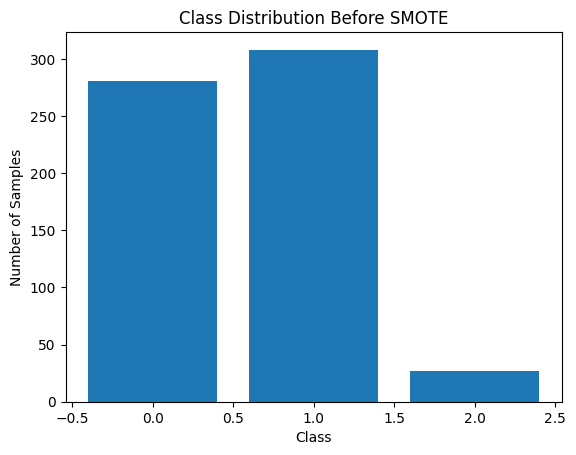

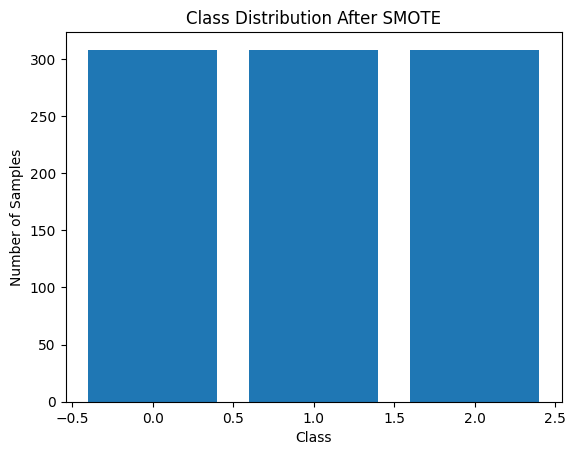

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from imblearn.over_sampling import SMOTE

# Original class distribution
counter_before = Counter(y_train)
print("Before SMOTE:", counter_before)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

counter_after = Counter(y_train_sm)
print("After SMOTE:", counter_after)

# Plot
plt.figure()
plt.bar(counter_before.keys(), counter_before.values())
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

plt.figure()
plt.bar(counter_after.keys(), counter_after.values())
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

In [110]:
from tensorflow.keras.layers import LSTM

lstm = Sequential([
    LSTM(64, return_sequences=False, input_shape=(X_tr_rnn.shape[1], 1)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(num_classes, activation="softmax")
])

lstm.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

hist_lstm = lstm.fit(
    X_tr_rnn, y_tr_cat,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
train_acc_lstm = lstm.evaluate(X_tr_rnn, y_tr_cat, verbose=0)[1]
test_probs_lstm = lstm.predict(X_te_rnn)
y_pred_lstm = np.argmax(test_probs_lstm, axis=1)

print("LSTM Train Acc:", train_acc_lstm)
print("LSTM Test Acc:", accuracy_score(y_te, y_pred_lstm))
print("Confusion Matrix:\n", confusion_matrix(y_te, y_pred_lstm))
print(classification_report(y_te, y_pred_lstm, zero_division=0))

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.3353 - loss: 1.0988 - val_accuracy: 0.3491 - val_loss: 1.0983
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3361 - loss: 1.0983 - val_accuracy: 0.3208 - val_loss: 1.0980
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3636 - loss: 1.0953 - val_accuracy: 0.3774 - val_loss: 1.0921
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3516 - loss: 1.0887 - val_accuracy: 0.5142 - val_loss: 1.0538
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4559 - loss: 1.0058 - val_accuracy: 0.6226 - val_loss: 0.8016
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5981 - loss: 0.8155 - val_accuracy: 0.5849 - val_loss: 0.7771
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6262 - loss: 0.7789 - val_accuracy: 0.6698 - val_loss: 0.8057
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5869 - loss: 0.8186 - val_accuracy: 0.6368 - val_l

In [ ]:
from tensorflow.keras.layers import LSTM
from tensorflow.keras.optimizers import Adam

lstm_tuned = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_tr_rnn.shape[1], 1)),
    Dropout(0.3),
    LSTM(64),
    Dense(32, activation="relu"),
    Dense(num_classes, activation="softmax")
])

lstm_tuned.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

hist_lstm2 = lstm_tuned.fit(
    X_tr_rnn, y_tr_cat,
    validation_split=0.2,
    epochs=120,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

train_acc_lstm2 = lstm_tuned.evaluate(X_tr_rnn, y_tr_cat, verbose=0)[1]
test_probs_lstm2 = lstm_tuned.predict(X_te_rnn)
y_pred_lstm2 = test_probs_lstm2.argmax(axis=1)

print("LSTM (tuned) Train Acc:", train_acc_lstm2)
print("LSTM (tuned) Test Acc:", (y_pred_lstm2 == y_te).mean())

Epoch 1/120


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.3332 - loss: 1.0988 - val_accuracy: 0.3302 - val_loss: 1.0952
Epoch 2/120
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.3823 - loss: 1.0916 - val_accuracy: 0.6038 - val_loss: 1.0531
Epoch 3/120
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5698 - loss: 0.9537 - val_accuracy: 0.7028 - val_loss: 0.6932
Epoch 4/120
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6578 - loss: 0.7016 - val_accuracy: 0.6274 - val_loss: 0.7446
Epoch 5/120
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6673 - loss: 0.6836 - val_accuracy: 0.7217 - val_loss: 0.6511
Epoch 6/120
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7012 - loss: 0.6414 - val_accuracy: 0.6792 - val_loss: 0.6246
Epoch 7/120
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6761 - loss: 0.6661 - val_accuracy: 0.7406 - val_loss: 0.6826
Epoch 8/120
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7313 - loss: 0.6250 - val_accuracy: 0.7406 - val_l

soil fertility depends on complex interactions between multiple features like N, P, K, pH and organic carbon. XGBoost models these non-linear interactions using multiple boosted trees and focuses on difficult samples, while also controlling overfitting through regularization. Other models either assume independence, rely on distance metrics, or are designed for sequential data, which makes them less suitable for this tabular dataset

# **Save the xgboost model**

In [ ]:
BASE_DIR = "/content/drive/MyDrive/case_study/models/models_soil_fertility"
import os, joblib

os.makedirs(BASE_DIR, exist_ok=True)

In [ ]:
joblib.dump(xgb_reg, f"{BASE_DIR}/xgb_model.pkl")
joblib.dump(scaler,  f"{BASE_DIR}/xgb_scaler.pkl")

# **Ann + data balanced**

In [ ]:
from tensorflow.keras.utils import to_categorical
import numpy as np

num_classes = len(np.unique(y_tr))
y_tr_cat = to_categorical(y_tr, num_classes=num_classes)
y_te_cat = to_categorical(y_te, num_classes=num_classes)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

ann = Sequential([
    Dense(128, activation="relu", input_shape=(X_tr.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

ann.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

In [ ]:
history_ann = ann.fit(
    X_tr, y_tr_cat,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

train_acc_ann = ann.evaluate(X_tr, y_tr_cat, verbose=0)[1]
y_pred_ann = ann.predict(X_te).argmax(axis=1)
test_acc_ann = accuracy_score(y_te, y_pred_ann)

print("ANN Train Acc:", train_acc_ann)
print("ANN Test Acc:", test_acc_ann)
print("Confusion Matrix:\n", confusion_matrix(y_te, y_pred_ann))
print(classification_report(y_te, y_pred_ann, zero_division=0))

# **ANN on the imbalanced dataset is better than on the balanced data**

# **Load saved**

In [ ]:
import joblib

xgb_loaded = joblib.load("/content/drive/MyDrive/case_study/models/models_soil_fertility/xgb_model.pkl")
scaler_loaded = joblib.load("/content/drive/MyDrive/case_study/models/models_soil_fertility/xgb_scaler.pkl")

print(type(xgb_loaded), type(scaler_loaded))


In [ ]:
import numpy as np

test_x = np.zeros((1, 12))
print("Prediction test:", xgb_loaded.predict(scaler_loaded.transform(test_x)))

In [ ]:
FEATURE_NAMES = ["N", "P", "K", "pH", "EC", "OC", "S", "Zn", "Fe", "Cu", "Mn", "B"]
CLASS_NAMES = ["Not Fertile", "Medium Fertile", "Highly Fertile"]

N	P	K	pH	EC	OC	S	Zn	Fe	Cu	Mn	B

In [ ]:
import numpy as np

CLASS_NAMES = ["Not Fertile", "Medium Fertile", "Highly Fertile"]

def predict_fertility_with_probs(N, P, K, pH, EC, OC, S, Zn, Fe, Cu, Mn, B):
    x = np.array([[float(N), float(P), float(K), float(pH), float(EC), float(OC),
                   float(S), float(Zn), float(Fe), float(Cu), float(Mn), float(B)]])

    x_scaled = scaler_loaded.transform(x)
    probs = xgb_loaded.predict_proba(x_scaled)[0]

    result = {
        "Not Fertile": float(probs[0]),
        "Medium Fertile": float(probs[1]),
        "Highly Fertile": float(probs[2])
    }
    return result

Build Gradio Interface

In [ ]:
!pip install gradio

N, P, K, pH, EC, OC,S, Zn, Fe, Cu Mn, B

In [ ]:
print("Model expects features:", xgb_loaded.n_features_in_)

In [ ]:
test_x = np.zeros((1, 12))
print("Prediction test:", xgb_loaded.predict(scaler_loaded.transform(test_x)))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = xgb_loaded.feature_importances_
features = ["N", "P", "K", "pH", "EC", "OC", "S", "Zn", "Fe", "Cu", "Mn", "B"]

fi = pd.Series(importances, index=features).sort_values(ascending=False)
fi.plot(kind="barh", figsize=(6,4), title="XGBoost Feature Importance")
plt.show()

# **Retraining of the model using NPK**

In [ ]:
X_NEW = df[["N", "P", "K", "pH"]]
y_NEW = df["Output"]

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_NEW)

In [ ]:
from sklearn.model_selection import train_test_split

X_N_train, X_N_test, y_N_train, y_N_test = train_test_split(
    X_NEW, y_NEW, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_N_train_res, y_N_train_res = smote.fit_resample(X_N_train, y_N_train)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_N_train_res)
X_test_scaled = scaler.transform(X_N_test)

In [ ]:
xgb_reg = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    min_child_weight=5,
    reg_lambda=2,
    reg_alpha=0.5,
    objective="multi:softmax",
    num_class=3,
    random_state=42
)

In [ ]:
xgb_reg.fit(X_N_train_scaled, y_N_train_res)

# **Predict on the test set**

In [ ]:
y_pred = xgb_reg.predict(X_N_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score
print("Train Accuracy:", xgb_reg.score(X_N_train_scaled, y_N_train_res))
print("Test Accuracy:", accuracy_score(y_N_test, y_pred))

# **Although additional soil parameters such as Organic Carbon and Electrical Conductivity may improve predictive accuracy, the proposed system targets real-time IoT deployment using low-cost soil sensors. Most commercially available field sensors reliably measure N, P, K, and pH. Therefore, the fertility classifier was redesigned to operate solely on these core soil macronutrient indicators.**



To keep the system clean and real time implementation features are reduces to NPK nad ph to have equally the same for both models( Fertility and crop recommendation)

In [ ]:
joblib.dump(xgb_reg, "/content/drive/MyDrive/case_study/models/models_soil_fertility/xgb_New_model.pkl")
joblib.dump(scaler, "/content/drive/MyDrive/case_study/models/models_soil_fertility/xgb_New_scaler.pkl")

In [ ]:
import numpy as np
import gradio as gr

CLASS_NAMES = ["Not Fertile", "Medium Fertile", "Highly Fertile"]

def predict_fertility_class(N, P, K, pH, EC, OC, S, Zn, Fe, Cu, Mn, B):
    # Build input in the exact training order
    x = np.array([[float(N), float(P), float(K), float(pH), float(EC), float(OC),
                   float(S), float(Zn), float(Fe), float(Cu), float(Mn), float(B)]])

    # Apply same preprocessing used in training
    x_scaled = scaler_loaded.transform(x)

    # Predict class
    pred = xgb_loaded.predict(x_scaled)[0]

    return CLASS_NAMES[int(pred)]

iface = gr.Interface(
    fn=predict_fertility_class,
    inputs=[
        gr.Number(label="Nitrogen (N)"),
        gr.Number(label="Phosphorus (P)"),
        gr.Number(label="Potassium (K)"),
        gr.Number(label="pH"),
        gr.Number(label="Electrical Conductivity (EC)"),
        gr.Number(label="Organic Carbon (OC)"),
        gr.Number(label="Sulfur (S)"),
        gr.Number(label="Zinc (Zn)"),
        gr.Number(label="Iron (Fe)"),
        gr.Number(label="Copper (Cu)"),
        gr.Number(label="Manganese (Mn)"),
        gr.Number(label="Boron (B)")
    ],
    outputs=gr.Textbox(label="Predicted Soil Fertility"),
    title="Soil Fertility Prediction (XGBoost)",
    description="Enter soil test values to predict fertility class."
)

iface.launch(share=True)

In [1]:
from google.colab import userdata
token = userdata.get('api_crop_recommendation')

In [2]:
!git clone https://$token@github.com/AkouHono/soil_fertility.git

Cloning into 'soil_fertility'...


In [3]:
%cd /content

/content


In [4]:
!ls

sample_data  soil_fertility


In [5]:
%cd /content/soil_fertility

/content/soil_fertility


In [10]:
!cp "/content/drive/MyDrive/case_study/Soil_Fertility.ipynb" .

cp: cannot stat '/content/drive/MyDrive/case_study/Soil_Fertility.ipynb': No such file or directory
